In [51]:
import pandas as pd

# Daten einlesen
df_2324 = pd.read_csv("../data/raw/bundesliga_2023_24.csv")
df_2425 = pd.read_csv("../data/raw/bundesliga_2024_25.csv")

In [52]:
# Erste Übersicht
df_2324.head()

df_2425.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,D1,23/08/2024,19:30,M'gladbach,Leverkusen,2,3,A,0.0,2.0,...,1.86,2.04,1.87,2.06,1.96,2.08,1.91,1.96,1.91,2.07
1,D1,24/08/2024,14:30,Augsburg,Werder Bremen,2,2,D,2.0,1.0,...,1.88,2.05,1.88,2.04,1.88,2.06,1.86,2.03,1.90,2.10
2,D1,24/08/2024,14:30,Freiburg,Stuttgart,3,1,H,1.0,1.0,...,1.95,1.98,1.95,1.97,1.98,2.09,1.87,2.00,1.95,2.04
3,D1,24/08/2024,14:30,Hoffenheim,Holstein Kiel,3,2,H,2.0,0.0,...,2.03,1.90,1.99,1.93,2.16,1.95,2.02,1.86,2.00,1.95
4,D1,24/08/2024,14:30,Mainz,Union Berlin,1,1,D,0.0,0.0,...,2.10,1.83,2.11,1.83,2.13,1.85,2.07,1.81,2.18,1.84


In [53]:
# Größe der Datensätze
df_2324.shape, df_2425.shape

# Spalten anzeigen
df_2324.columns.tolist()

['Div',
 'Date',
 'Time',
 'HomeTeam',
 'AwayTeam',
 'FTHG',
 'FTAG',
 'FTR',
 'HTHG',
 'HTAG',
 'HTR',
 'HS',
 'AS',
 'HST',
 'AST',
 'HF',
 'AF',
 'HC',
 'AC',
 'HY',
 'AY',
 'HR',
 'AR',
 'B365H',
 'B365D',
 'B365A',
 'BWH',
 'BWD',
 'BWA',
 'IWH',
 'IWD',
 'IWA',
 'PSH',
 'PSD',
 'PSA',
 'WHH',
 'WHD',
 'WHA',
 'VCH',
 'VCD',
 'VCA',
 'MaxH',
 'MaxD',
 'MaxA',
 'AvgH',
 'AvgD',
 'AvgA',
 'B365>2.5',
 'B365<2.5',
 'P>2.5',
 'P<2.5',
 'Max>2.5',
 'Max<2.5',
 'Avg>2.5',
 'Avg<2.5',
 'AHh',
 'B365AHH',
 'B365AHA',
 'PAHH',
 'PAHA',
 'MaxAHH',
 'MaxAHA',
 'AvgAHH',
 'AvgAHA',
 'B365CH',
 'B365CD',
 'B365CA',
 'BWCH',
 'BWCD',
 'BWCA',
 'IWCH',
 'IWCD',
 'IWCA',
 'PSCH',
 'PSCD',
 'PSCA',
 'WHCH',
 'WHCD',
 'WHCA',
 'VCCH',
 'VCCD',
 'VCCA',
 'MaxCH',
 'MaxCD',
 'MaxCA',
 'AvgCH',
 'AvgCD',
 'AvgCA',
 'B365C>2.5',
 'B365C<2.5',
 'PC>2.5',
 'PC<2.5',
 'MaxC>2.5',
 'MaxC<2.5',
 'AvgC>2.5',
 'AvgC<2.5',
 'AHCh',
 'B365CAHH',
 'B365CAHA',
 'PCAHH',
 'PCAHA',
 'MaxCAHH',
 'MaxCAHA',
 'AvgCAHH

In [54]:
# Relevante Spalten
relevant_cols = ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR"]

df_2324[relevant_cols].head()

df_2425[relevant_cols].head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR
0,23/08/2024,M'gladbach,Leverkusen,2,3,A
1,24/08/2024,Augsburg,Werder Bremen,2,2,D
2,24/08/2024,Freiburg,Stuttgart,3,1,H
3,24/08/2024,Hoffenheim,Holstein Kiel,3,2,H
4,24/08/2024,Mainz,Union Berlin,1,1,D


In [55]:
# Datum umwandeln
df_2324["Date"] = pd.to_datetime(df_2324["Date"], dayfirst=True)
df_2425["Date"] = pd.to_datetime(df_2425["Date"], dayfirst=True)

# Saison hinzufügen
df_2324["Season"] = "2023/24"
df_2425["Season"] = "2024/25"

C:\Users\BERKE\AppData\Local\Temp\ipykernel_15940\1760375308.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_2425["Season"] = "2024/25"


In [56]:
# Nur relevante Spalten behalten
cols = ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "Season"]

df_2324 = df_2324[cols]
df_2425 = df_2425[cols]

In [57]:
# Datensätze zusammenführen
df = pd.concat([df_2324, df_2425], ignore_index=True)

# Sortieren
df = df.sort_values("Date").reset_index(drop=True)

In [58]:
# Kontrolle
df.head()

df.tail()

df.shape

df["Season"].value_counts()

Season
2023/24    306
2024/25    306
Name: count, dtype: int64

In [59]:
# Ergebnisse insgesamt zählen
df["FTR"].value_counts()

# Ergebnisse pro Saison vergleichen
df.groupby("Season")["FTR"].value_counts()

Season   FTR
2023/24  H      134
         A       91
         D       81
2024/25  H      118
         A      111
         D       77
Name: count, dtype: int64

In [60]:
# Durchschnittliche Tore
df.groupby("Season")[["FTHG", "FTAG"]].mean()

# Gesamttore
df["TotalGoals"] = df["FTHG"] + df["FTAG"]

df.groupby("Season")["TotalGoals"].mean()

Season
2023/24    3.218954
2024/25    3.133987
Name: TotalGoals, dtype: float64

In [61]:
# Prozentuale Verteilung
df.groupby("Season")["FTR"].value_counts(normalize=True) * 100

Season   FTR
2023/24  H      43.790850
         A      29.738562
         D      26.470588
2024/25  H      38.562092
         A      36.274510
         D      25.163399
Name: proportion, dtype: float64

In [62]:
# Statistische Übersicht
df.describe()

,Date,FTHG,FTAG,TotalGoals
count,612,612.000000,612.000000,612.000000
mean,2024-07-09 15:52:56.470588,1.718954,1.457516,3.176471
min,2023-08-18 00:00:00,0.000000,0.000000,0.000000
25%,2024-01-20 00:00:00,1.000000,0.750000,2.000000
50%,2024-07-05 12:00:00,2.000000,1.000000,3.000000
75%,2025-01-15 12:00:00,3.000000,2.000000,4.000000
max,2025-05-17 00:00:00,8.000000,6.000000,9.000000
std,NaN,1.419792,1.246859,1.773113


## Erste deskriptive Analyse

In diesem Schritt wurden die beiden Datensätze (Saison 2023/24 und 2024/25) zusammengeführt und erste Kennzahlen berechnet.

Dabei wurde untersucht:
- Verteilung der Spielergebnisse (Heimsieg, Unentschieden, Auswärtssieg)
- durchschnittliche Anzahl an Toren pro Spiel
- Unterschiede zwischen den beiden Saisons

Erste Ergebnisse zeigen, dass Heimsiege etwas häufiger auftreten als Auswärtssiege. Außerdem lassen sich leichte Unterschiede zwischen den Saisons erkennen.

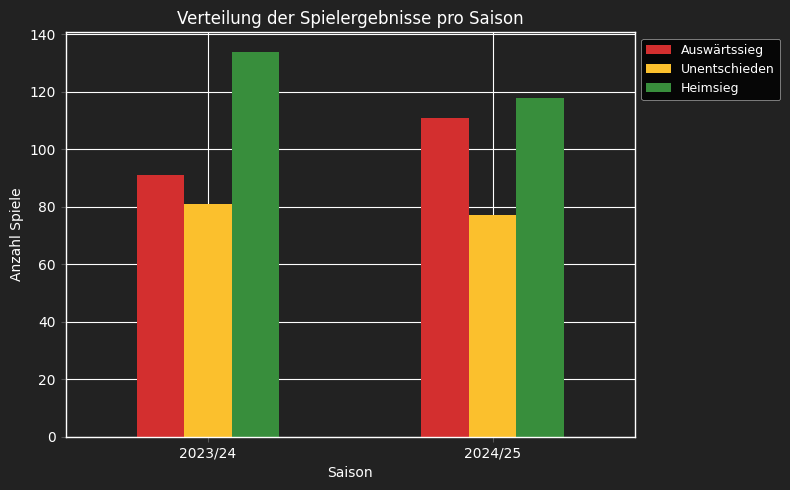

In [63]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 9

# Ergebnisse pro Saison zählen
result_counts = df.groupby("Season")["FTR"].value_counts().unstack()

result_counts


result_counts.plot(
    kind="bar",
    color=["#d32f2f", "#fbc02d", "#388e3c"]  # Rot, Gelb, Grün
)

plt.title("Verteilung der Spielergebnisse pro Saison", color="white")
plt.xlabel("Saison", color="white")
plt.ylabel("Anzahl Spiele", color="white")

plt.xticks(color="white")
plt.yticks(color="white")

plt.legend(
    ["Auswärtssieg", "Unentschieden", "Heimsieg"],
    loc="upper left",
    bbox_to_anchor=(1, 1),
    facecolor="black",
    labelcolor="white"
)

plt.gca().set_facecolor("#222222")   # dunkler Hintergrund
plt.gcf().patch.set_facecolor("#222222")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


### Verteilung der Spielergebnisse

Die Grafik zeigt die Anzahl von Heim-, Unentschieden- und Auswärtssiegen in den beiden betrachteten Saisons.

Auffällig ist, dass Heimsiege in beiden Saisons am häufigsten auftreten.
Unentschieden kommen deutlich seltener vor.

Im Vergleich der beiden Saisons zeigt sich, dass in der Saison 2024/25 mehr Auswärtssiege erzielt wurden als in der Saison 2023/24.

Insgesamt lassen sich Unterschiede in der Verteilung der Spielergebnisse zwischen den beiden Saisons erkennen.

In [64]:
# Durchschnittliche Heim und Auswärtstore pro saison
goals_mean = df.groupby("Season")[["FTHG", "FTAG"]].mean()

goals_mean

,FTHG,FTAG
Season,,
2023/24,1.807190,1.411765
2024/25,1.630719,1.503268


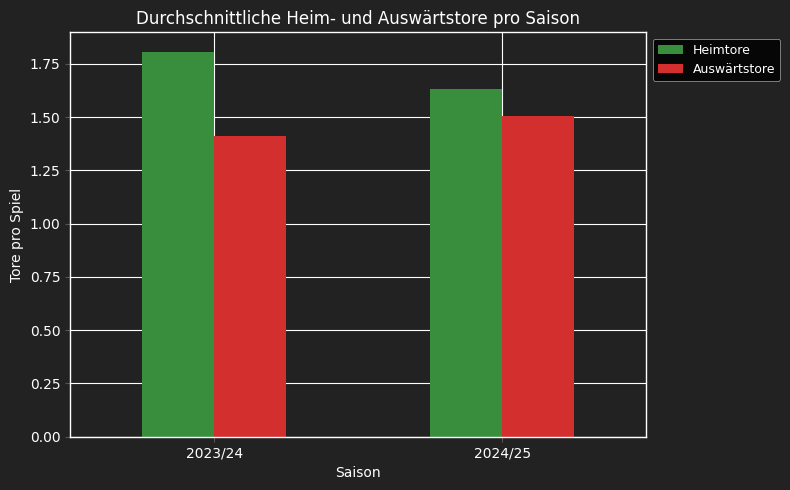

In [65]:
goals_mean.plot(
    kind="bar",
    color=["#388e3c", "#d32f2f"]
)

plt.title("Durchschnittliche Heim- und Auswärtstore pro Saison", color="white")
plt.xlabel("Saison", color="white")
plt.ylabel("Tore pro Spiel", color="white")

plt.xticks(rotation=0, color="white")
plt.yticks(color="white")

plt.legend(
    ["Heimtore", "Auswärtstore"],
    loc="upper left",
    bbox_to_anchor=(1, 1),
    facecolor="black",
    labelcolor="white"
)

plt.gca().set_facecolor("#222222")
plt.gcf().patch.set_facecolor("#222222")

plt.tight_layout()
plt.show()

### Durchschnittliche Heim und Auswärtstore

Die Grafik zeigt die durchschnittliche Anzahl an Heim und Auswärtstoren pro Spiel in den beiden betrachteten Saisons.

Dabei ist zu erkennen, dass in beiden Saisons im Durchschnitt mehr Heimtore als Auswärtstore erzielt wurden. Das spricht für einen leichten Heimvorteil.

Außerdem lassen sich kleine Unterschiede zwischen den beiden Spielzeiten erkennen, was für die spätere Analyse mit dem Elo-Modell relevant sein kann.

## Vorbereitung des Elo Ratings

In [66]:
# Alle Teams extrahieren
teams = pd.concat([df["HomeTeam"], df["AwayTeam"]]).unique()

teams

<StringArray>
['Werder Bremen',      'Augsburg',    'Hoffenheim',    'Leverkusen',
     'Stuttgart',     'Wolfsburg',      'Dortmund',  'Union Berlin',
 'Ein Frankfurt',    'RB Leipzig',    'M'gladbach',    'Heidenheim',
      'Freiburg',        'Bochum',     'Darmstadt',       'FC Koln',
         'Mainz', 'Bayern Munich',      'St Pauli', 'Holstein Kiel']
Length: 20, dtype: str

In [67]:
len(teams)

20

In [68]:
# Start-Elo für jedes Team
elo_ratings = {}

for team in teams:
    elo_ratings[team] = 1500

elo_ratings

{'Werder Bremen': 1500,
 'Augsburg': 1500,
 'Hoffenheim': 1500,
 'Leverkusen': 1500,
 'Stuttgart': 1500,
 'Wolfsburg': 1500,
 'Dortmund': 1500,
 'Union Berlin': 1500,
 'Ein Frankfurt': 1500,
 'RB Leipzig': 1500,
 "M'gladbach": 1500,
 'Heidenheim': 1500,
 'Freiburg': 1500,
 'Bochum': 1500,
 'Darmstadt': 1500,
 'FC Koln': 1500,
 'Mainz': 1500,
 'Bayern Munich': 1500,
 'St Pauli': 1500,
 'Holstein Kiel': 1500}

In [69]:
# Test
elo_ratings["Bayern Munich"]

1500

Für die Berechnung des Elo Ratings wurden zunächst alle Daten extrahiert. Jedem Team wird ein Startwert von 1500 zugewiesen. Dieser Wert dient als Ausgangspunkt für die spätere Berechnung der teamstärken.
Im weiteren Verlauf wird das Rating nach jedem Spiel basierend auf dem Ergebnis angepasst.

## Erwartungswert im Elo Modell


In [70]:
# Funktion für den erwarteten Score
def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

In [71]:
# Test (muss 0.5 sein)
expected_score(1500, 1500)

0.5

In [72]:
# Test (muss größer 0.5 sein)
expected_score(1600, 1500)

0.6400649998028851

In [73]:
# Test (muss kleiner 0.5 sein)
expected_score(1400, 1500)

0.35993500019711494

Im Elo System wird zunächst berechnet, wie hoch die erwartete Punktzahl eines teams vor dem Spiel ist.
Je größer der Unterschied zwischen zwei Ratings ist, desto höher ist die erwartete Gewinnwahrscheinlichkeit des stärkeren Teams.
Im nächsten Schritt wird diese Erwartung mit dem tatsächlichen Ergebnis verglichen.

## Aktualisierung des Elo Ratings

In [74]:
# K-Faktor festlegen
K = 20

In [75]:
def update_elo(rating, expected, actual, k=20):
    return rating + k * (actual - expected)

In [76]:
# Beispiel: Team gewinnt, obwohl Erwartung nur 0.4 war
update_elo(1500, 0.4, 1)

1512.0

In [77]:
# Beispiel: Team verliert, obwohl Erwartung hoch war
update_elo(1500, 0.7, 0)

1486.0

Nach jedem Spiel wird das Rating eines Teams basierend auf dem tatsächlichen Ergebnis und dem erwarteten Ergebnis angepasst.
Ein Sieg führt zu einem Anstieg des Ratings, eine Niederlage zu einem Rückgang. Die Höhe der Anpassung hängt vom Unterschied zwischen Erwartung und Ergebnis ab.

## Anwendung des Elo Modells auf alle Spiele

In [78]:
# Ratings neu initialisieren
elo_ratings = {}

for team in teams:
    elo_ratings[team] = 1500

In [79]:
# Listen für Ratings vor dem Spiel
home_elo_before = []
away_elo_before = []

In [80]:
for _, row in df.iterrows():
    home_team = row["HomeTeam"]
    away_team = row["AwayTeam"]

    home_rating = elo_ratings[home_team]
    away_rating = elo_ratings[away_team]

    home_elo_before.append(home_rating)
    away_elo_before.append(away_rating)

    expected_home = expected_score(home_rating, away_rating)
    expected_away = expected_score(away_rating, home_rating)

    if row["FTR"] == "H":
        actual_home = 1
        actual_away = 0
    elif row["FTR"] == "D":
        actual_home = 0.5
        actual_away = 0.5
    else:
        actual_home = 0
        actual_away = 1

    new_home_rating = update_elo(home_rating, expected_home, actual_home, K)
    new_away_rating = update_elo(away_rating, expected_away, actual_away, K)

    elo_ratings[home_team] = new_home_rating
    elo_ratings[away_team] = new_away_rating

In [81]:
# Ratings vor dem Spiel in den Datensatz schreiben
df["HomeEloBefore"] = home_elo_before
df["AwayEloBefore"] = away_elo_before

In [82]:
df[["Date", "HomeTeam", "AwayTeam", "HomeEloBefore", "AwayEloBefore", "FTR"]].head(10)

,Date,HomeTeam,AwayTeam,HomeEloBefore,AwayEloBefore,FTR
0,2023-08-18,Werder Bremen,Bayern Munich,1500.0,1500.0,A
1,2023-08-19,Augsburg,M'gladbach,1500.0,1500.0,D
2,2023-08-19,Hoffenheim,Freiburg,1500.0,1500.0,A
3,2023-08-19,Leverkusen,RB Leipzig,1500.0,1500.0,H
4,2023-08-19,Stuttgart,Bochum,1500.0,1500.0,H
5,2023-08-19,Wolfsburg,Heidenheim,1500.0,1500.0,H
6,2023-08-19,Dortmund,FC Koln,1500.0,1500.0,H
7,2023-08-20,Union Berlin,Mainz,1500.0,1500.0,H
8,2023-08-20,Ein Frankfurt,Darmstadt,1500.0,1500.0,H
9,2023-08-25,RB Leipzig,Stuttgart,1490.0,1510.0,H


In [83]:
# Aktuelle Ratings nach allen Spielen
elo_ratings

{'Werder Bremen': 1526.8806921884238,
 'Augsburg': 1477.0065727463364,
 'Hoffenheim': 1448.1451129319012,
 'Leverkusen': 1678.1512185405527,
 'Stuttgart': 1555.961843448436,
 'Wolfsburg': 1467.237757234868,
 'Dortmund': 1585.4452925508735,
 'Union Berlin': 1460.3816565934997,
 'Ein Frankfurt': 1566.8807339267412,
 'RB Leipzig': 1548.9972417875176,
 "M'gladbach": 1463.4195598183212,
 'Heidenheim': 1426.546868493311,
 'Freiburg': 1529.759706871611,
 'Bochum': 1395.979118012767,
 'Darmstadt': 1362.4964491692215,
 'FC Koln': 1429.553036575522,
 'Mainz': 1526.2432486604196,
 'Bayern Munich': 1684.0090245907988,
 'St Pauli': 1446.540560735935,
 'Holstein Kiel': 1420.3643051229435}



In diesem Schritt wurde das Elo Modell auf alle Spiele angewendet. Dafür wurden die Ratings der Teams zunächst initialisiert und anschließend für jedes Spiel basierend auf Erwartung und tatsächlichem Ergebnis aktualisiert.

Dabei wurde für jedes Spiel das Elo Rating vor dem Spiel gespeichert, sodass eine spätere analyse möglich ist.

Die berechneten Elo Werte zeigen, dass sich die Teams im Verlauf der Saisons unterschiedlich entwickeln. Stärkere Teams erreichen höhere Ratings, während schwächere Teams entsprechend niedrigere Werte haben.

### Elo Tabelle

In [84]:
elo_table = pd.DataFrame(
    elo_ratings.items(),
    columns=["Team", "Elo"]
)

elo_table = elo_table.sort_values("Elo", ascending=False).reset_index(drop=True)

elo_table

,Team,Elo
0,Bayern Munich,1684.009025
1,Leverkusen,1678.151219
2,Dortmund,1585.445293
3,Ein Frankfurt,1566.880734
4,Stuttgart,1555.961843
5,RB Leipzig,1548.997242
6,Freiburg,1529.759707
7,Werder Bremen,1526.880692
8,Mainz,1526.243249
9,Augsburg,1477.006573


In [85]:
elo_table.head(10)

,Team,Elo
0,Bayern Munich,1684.009025
1,Leverkusen,1678.151219
2,Dortmund,1585.445293
3,Ein Frankfurt,1566.880734
4,Stuttgart,1555.961843
5,RB Leipzig,1548.997242
6,Freiburg,1529.759707
7,Werder Bremen,1526.880692
8,Mainz,1526.243249
9,Augsburg,1477.006573



Die Tabelle zeigt die finalen Elo Werte aller Teams nach Anwendung des Modells auf beide Saisons. Dabei ist zu beachten, dass die beiden Saisons gemeinsam ausgewertet wurden. Das bedeutet, dass sich die Elo Werte über den gesamten Zeitraum hinweg entwickeln und nicht getrennt pro Saison betrachtet werden.

Auffällig ist, dass Teams wie Bayern München und Leverkusen hohe Elo Werte erreichen, was grundsätzlich zu den sportlichen Leistungen passt. Gleichzeitig kann diese gemeinsame Betrachtung zu Verzerrungen führen, da sich die Teamzusammensetzung zwischen den Saisons verändert (z. B. Auf und Absteiger).

Diese erste Elo Tabelle dient daher als Ausgangspunkt für weitere Analysen, insbesondere für einen späteren Vergleich der einzelnen Saisons.

## Vorbereitung des Saisonvergleichs

Da sich die Teamzusammensetzung zwischen den beiden Saisons verändert, werden die Daten im nächsten Schritt getrennt betrachtet.

Dadurch kann später untersucht werden, wie sich die Elo Werte und Ergebnisse in den beiden Spielzeiten jeweils entwickeln.

In [86]:
# Datensätze nach Saison trennen
df_2324_only = df[df["Season"] == "2023/24"].copy()
df_2425_only = df[df["Season"] == "2024/25"].copy()

In [87]:
# Größen der beiden Saison-Datensätze prüfen
df_2324_only.shape, df_2425_only.shape

((306, 10), (306, 10))

In [88]:
# Erste Zeilen anschauen
df_2324_only.head()

df_2425_only.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,Season,TotalGoals,HomeEloBefore,AwayEloBefore
306,2024-08-23,M'gladbach,Leverkusen,2,3,A,2024/25,5,1450.350332,1681.465636
307,2024-08-24,Augsburg,Werder Bremen,2,2,D,2024/25,4,1463.281489,1494.095786
308,2024-08-24,Freiburg,Stuttgart,3,1,H,2024/25,4,1467.457019,1609.612651
309,2024-08-24,Hoffenheim,Holstein Kiel,3,2,H,2024/25,5,1496.453113,1500.000000
310,2024-08-24,Mainz,Union Berlin,1,1,D,2024/25,2,1484.035267,1438.767799


In [89]:
# Teams pro Saison prüfen
teams_2324 = pd.concat([df_2324_only["HomeTeam"], df_2324_only["AwayTeam"]]).unique()
teams_2425 = pd.concat([df_2425_only["HomeTeam"], df_2425_only["AwayTeam"]]).unique()

len(teams_2324), len(teams_2425)

(18, 18)

In [90]:
sorted(teams_2324)

['Augsburg',
 'Bayern Munich',
 'Bochum',
 'Darmstadt',
 'Dortmund',
 'Ein Frankfurt',
 'FC Koln',
 'Freiburg',
 'Heidenheim',
 'Hoffenheim',
 'Leverkusen',
 "M'gladbach",
 'Mainz',
 'RB Leipzig',
 'Stuttgart',
 'Union Berlin',
 'Werder Bremen',
 'Wolfsburg']

In [91]:
sorted(teams_2425)

['Augsburg',
 'Bayern Munich',
 'Bochum',
 'Dortmund',
 'Ein Frankfurt',
 'Freiburg',
 'Heidenheim',
 'Hoffenheim',
 'Holstein Kiel',
 'Leverkusen',
 "M'gladbach",
 'Mainz',
 'RB Leipzig',
 'St Pauli',
 'Stuttgart',
 'Union Berlin',
 'Werder Bremen',
 'Wolfsburg']

In diesem Schritt wurden die beiden Saisons getrennt betrachtet, um die Daten später gezielter vergleichen zu können.

Dafür wurde der gemeinsame Datensatz in zwei einzelne Datensätze für die Saisons 2023/24 und 2024/25 aufgeteilt. Anschließend wurde geprüft, ob beide Datensätze die erwartete Anzahl an Spielen enthalten.

Außerdem wurde die Teamzusammensetzung beider Saisons verglichen. Dabei zeigt sich, dass sich die Teams zwischen den Spielzeiten teilweise unterscheiden, was für die spätere Elo Analyse relevant ist.